In [1]:
"""
 
gowalla.ipynb
- Trm4Rec把直接打分所有item
- 换成 先预测 tree path -> 再还原 item -> 再 rerank

gowalla.ipynb 里的设计：
- 多棵树共享同一个 encoder
- 每棵树有自己的 decoder

为什么只保存 decoder 因为 gowalla.ipynb 训练时是：
- tree 0 的 encoder 被共享给所有树
- 各树 decoder 各自不同

所以存储时最省事的方式就是：
- encoder 存一次
- decoder 每棵树各存一次

一句话 这个 .pt 文件不是整个推荐模型，而是：多树 Trm4Rec 系统中，
- 各个树共享的encoder 参数文件
- 第0-3棵树各自的 decoder 参数文件
"""

from typing import Any, List

import torch
import numpy as np
import os
import sys
import time
import math

sys.path.append('../..')

#=========parametres=========#
# 数据与设备
data_set_name = 'gowalla'   # the name of the dataset
device = 'cpu'              # the device to use. 'cuda:4' for gpu
rerank_topk = 20            # rerank 阶段输出 top-k
topk = 20                   # 各树召回阶段 top-k
have_processed_data = True  # 默认直接使用现成预处理文件

# 多树 Trm4Rec 配置
tree_num = 4                # the number of trees
num_layers = 1              # layer of transformer
k = 18                      # the branch of each tree. 树的分支数 k=18. 因为 item 数是 71436，所以树高大约是 4（18^4 = 104976，足够覆盖所有 item）
n_head = 4                  # 多头注意力头数
d_model = 96                # Transformer 隐层维度
train_sample_seg_cnt = 10   # 训练 shard 数
parall = 10                 # the number of parallel processes
seq_len = 70                # 样本总长度，历史 69 + label 1
min_seq_len = 15            # 过滤过短用户序列
test_user_num = 1000        # 旧 raw 分支里测试用户数

# 各种路径字符串
raw_data_file               = '../../data/{}/{}.txt'.format(data_set_name,data_set_name)    # the raw data file
train_instances_file        = '../../data/{}/train_instances'.format(data_set_name)         # the train instances file
test_instances_file         = '../../data/{}/test_instances'.format(data_set_name)          # the test instances file
validation_instances_file   = '../../data/{}/validation_instances'.format(data_set_name)    # the validation instances file
user_item_num_file          = '../../data/{}/user_item_num.txt'.format(data_set_name)       # the user item num file
train_item_vec_file         = '../../data/{}/train_item_vec.npy'.format(data_set_name)      # the train item vec file
# item_to_code_file         ='../../data/{}/item_to_code.npy'.format(data_set_name)         # the item to code file
# code_to_item_file         ='../../data/{}/code_to_item.npy'.format(data_set_name)         # the code to item file
DIN_Model_path              = '../../data/{}/DIN_MODEL.pt'.format(data_set_name)            # the din model path

# 树配置
tree_has_generated          = True      # 直接读取已有树文件. 不要现场建树, 直接从 data/gowalla/tree/*.npy 读已有树编码
init_way                    = 'embkm'   # 树初始化方式：embkm, embedding-based kmeans
feature_ratio               = 1.0       # 树构造时使用全部特征
reranker                    = "Trm"     # rerank 方式标签
max_iters                   = 100       # kmeans / tree 构造最大迭代次数
total_batch_num             = 20000     # 训练最大 batch 数
test_batch_size             = 50        # 测试 batch 大小

# 树文件路径列表
item_to_code_file_list      = []        # 4 个 item_to_code 文件路径
code_to_item_file_list      = []        # 4 个 code_to_item 文件路径
for tree_id in range(tree_num):
    item_to_code_file='../../data/{}/tree/{}{}_item_to_code_tree_id_{}_k{}.npy'.format(data_set_name, init_way, feature_ratio, tree_id, k)
    code_to_item_file='../../data/{}/tree/{}{}_code_to_item_tree_id_{}_k{}.npy'.format(data_set_name, init_way, feature_ratio, tree_id, k)
    item_to_code_file_list.append(item_to_code_file)
    code_to_item_file_list.append(code_to_item_file)
#assert tree_num==1

eps=0.000001 # 用于数值稳定、避免除 0
if device!='cpu':
    torch.cuda.set_device(device)
    device='cuda'

# IPython magic. 自动重载
%load_ext autoreload
# 模式2：每次执行cell前，自动重载所有变更过的模块
%autoreload 2

In [2]:
"""load DIN model which is the ranker for fine-ranking
加载一个已经训练好的 DIN 模型, 准备用它做最终重排(fine-ranking/rerank)

也就是作者原本的设想是：
1. 先用多棵 Trm4Rec 树召回一批候选 item
2. 再用 DIN_Model 对这些候选 item 重新打分
3. 按 DIN 分数做最终排序

所以这里的 DIN 角色不是主召回模型，而是：精排模型 / reranker
"""

from lib import DeepInterestNetwork as DIN

DIN_Model = torch.load(DIN_Model_path, map_location=torch.device(device), weights_only=False)
DIN_Model.eval()
pass

In [3]:
import lib
from lib import Trm4Rec
from lib import generate_train_and_test_data
import gc
import numpy as np

[user_num, item_num] = np.loadtxt(user_item_num_file, dtype=np.int32, delimiter=',')
print('user num is {}, item is {}'.format(user_num, item_num))

user num is 13583, item is 71436


In [4]:
"""
真正把磁盘上的预处理样本文件加载成内存对象
"""

from lib.generate_training_batches import Train_instance

train_instances = Train_instance(parall=parall)

# 旧路径: 每轮重新从文件读取数据 -> 再产出 batch
# training_batch_generator = train_instances.training_batches(
#     train_instances_file,
#     train_sample_seg_cnt,
#     item_num,
#     batchsize=training_batch_size
# )

# 新路径: 先一次性把训练数据都读入内存 -> 然后在内存里反复出 batch
training_data, training_labels = train_instances.get_training_data(
    train_instances_file, 
    train_sample_seg_cnt, 
    item_num
)

# 训练 batch 生成器(无限batch流)
# shape: [691776, 69], [691776]
training_batch_generator = train_instances.generate_training_records(
    training_data,
    training_labels,
    batch_size=256
)

# 验证 batch 生成器(无限batch流)
validation_batch_generator = train_instances.validation_batches(
    validation_instances_file, 
    item_num, 
    batchsize=test_batch_size
)

# 测试 batch 生成器(无限batch流)
test_batch_generator = train_instances.test_batches(
    test_instances_file,
    item_num,
    batchsize=test_batch_size
)

test_instances: torch.Tensor = train_instances.read_test_instances_file(test_instances_file, item_num)

In [5]:
from pandas import DataFrame
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

moving_average = lambda x, **kw: DataFrame({'x':np.asarray(x)}).x.ewm(**kw).mean().values

# 训练指标
train_loss_history = []         # 训练损失
train_precision_history = []    # 训练精确率
train_recall_history = []       # 训练召回率
train_f_measure_history = []    # 训练F1值（综合指标）
train_novelty_history = []      # 训练新颖度
train_policy_acc = []           # 训练策略准确率
train_hr_history = []           # 训练点击率
train_ndcg_history = []         # 训练DCG@10
train_map_history = []          # 训练MAP@10

# 测试指标
test_precision_history = []     # 测试精确率
test_recall_history = []        # 测试召回率
test_f_measure_history = []     # 测试F1值（综合指标）
test_novelty_history = []      # 测试新颖度
test_hr_history = []           # 测试点击率
test_ndcg_history = []         # 测试DCG@10
test_map_history = []          # 测试MAP@10

In [6]:
# 1. Precision（精确率）
# 推荐的结果里，有多少是用户真正喜欢的 -> 越高说明推荐越准
def precision(result_list, gt_list, top_k: int):
    """计算precision指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param top_k: int, 推荐结果的长度
    :return: float, precision指标的值
    """
    count = 0.0
    for r, g in zip(result_list, gt_list):
        count += 1.0 * len(set(r).intersection(set(g))) / top_k
    return count / len(result_list)


# 2. Recall（召回率）
# 用户喜欢的东西，有多少被你推荐出来了 -> 越高说明覆盖越全
def recall(result_list, gt_list):
    """计算recall指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, recall指标的值
    """
    t = 0.0
    for r, g in zip(result_list, gt_list):
        t += 1.0 * len(set(r).intersection(set(g))) / len(g)
    return t / len(result_list)


# 3. F-measure（F1 分数）
# Precision + Recall 的综合分数 -> 越高说明整体效果越好
def f_measure(result_list, gt_list, top_k, eps=1.0e-9):
    """计算f_measure指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param top_k: int, 推荐结果的长度
    :param eps: float, 防止除零的极小值
    :return: float, f_measure指标的值
    """
    f = 0.0
    for r, g in zip(result_list, gt_list):
        precision = 1.0 * len(set(r).intersection(set(g))) / top_k
        recall = 1.0 * len(set(r).intersection(set(g))) / len(g)
        if recall + precision < eps:
            continue
        f += (2 * recall * precision) / (recall + precision)
    return f / len(result_list)


# 4. Novelty（新颖度）
# 推荐结果的多样性 / 新奇度 -> 越高说明推荐不重复、不单调
def novelty(result_list, s_u, top_k):
    """计算novelty指标
    :param result_list: list of list, 每个list是一个用户的推荐结果, 已经处理为topK
    :param s_u: list of list, 每个list是一个用户的历史点击结果
    :param top_k: int, 推荐结果的长度
    :return: float, novelty指标的值
    """
    count = 0.0
    for r, g in zip(result_list, s_u):
        count += 1.0 * len(set(r) - set(g)) / top_k
    return count / len(result_list)


def hit_ratio(result_list, gt_list):
    """计算hit_ratio指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, hit_ratio指标的值
    """
    intersect_set = [len(set(r) & set(g)) for r, g in zip(result_list, gt_list)]
    return 1.0 * sum(intersect_set) / sum([len(gts) for gts in gt_list])


def NDCG(result_list, gt_list):
    """计算NDCG指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, NDCG指标的值
    """
    t = 0.0
    for re, gt in zip(result_list, gt_list):
        setgt = set(gt)
        indicator = np.asarray([1 if r in setgt else 0 for r in re])
        sorted_indicator = np.ones(min(len(setgt), len(re)))
        if 1 in indicator:
            t += np.sum(indicator / np.log2(1.0 * np.arange(2, len(indicator) + 2))) / np.sum(sorted_indicator / np.log2(1.0 * np.arange(2, len(sorted_indicator) + 2)))
    return t / len(gt_list)


def MAP(result_list, gt_list, topk):
    """计算MAP指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param topk: int, 推荐结果的长度
    :return: float, MAP指标的值
    """
    t = 0.0
    for re, gt in zip(result_list, gt_list):
        setgt = set(gt)
        indicator = np.asarray([1 if r in setgt else 0 for r in re])
        t += np.mean([indicator[:i].sum(-1) / i for i in range(1, topk + 1)], axis=-1)
    return t / len(gt_list)

In [7]:
# data = DIN_Model.item_embedding.embed.weight.data[:item_num,:].cpu()

optimizer = lambda params: torch.optim.Adam(params, lr=1e-3, amsgrad=True)

# fixme: 现场建树是什么意思?
data = None

# fixme: encoder和decoder分别是什么? 有什么用?

# 循环创建 tree_num=4 个 Trm4Rec 模型
train_model_list: list[Trm4Rec] = []
for i in range(tree_num):
    train_model = Trm4Rec(
        item_num=int(item_num),
        user_seq_len=seq_len-1,
        d_model=d_model,
        nhead=n_head,
        device=device,
        num_layers=num_layers,
        k=k,
        item_to_code_file=item_to_code_file_list[i],
        code_to_item_file=code_to_item_file_list[i],
        tree_has_generated=tree_has_generated,
        init_way=init_way,
        max_iters=max_iters,
        feature_ratio=feature_ratio,
        data=data,#used for kmeans tree
        parall=parall
    )
    # 从第 2 棵树开始，把它们的 encoder 指向第 0 棵树的 encoder，实现 多树共享 encoder
    if i > 0:
        train_model.trm_model.trm.encoder = train_model_list[0].trm_model.trm.encoder
    train_model_list.append(train_model)

HFTransformerModel(
  (trm): EncoderDecoderModel(
    (encoder): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(71437, 96, padding_idx=71436)
        (position_embeddings): Embedding(70, 96)
        (token_type_embeddings): Embedding(2, 96)
        (LayerNorm): LayerNorm((96,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0): BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=96, out_features=96, bias=True)
                (key): Linear(in_features=96, out_features=96, bias=True)
                (value): Linear(in_features=96, out_features=96, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=96, out_features=96, bias=True)
          

In [9]:
# model_file='../../data/{}/model/{}{}_model_encoder_k{}.pt'.format(data_set_name, init_way, feature_ratio, k)
# model_encoder = torch.load(model_file, map_location=torch.device(device))

# for tree_id in range(tree_num):
#     model_file='../../data/{}/model/{}{}_model_decoder_tree_id_{}_k{}.pt'.format(data_set_name, init_way, feature_ratio, tree_id, k)
#     train_model_list[tree_id].trm_model.trm.encoder = model_encoder
#     train_model_list[tree_id].trm_model.trm.decoder = torch.load(model_file, map_location=torch.device(device))
#     train_model_list[tree_id].trm_model.eval()

In [ ]:
# "共享 encoder + 4 个独立 decoder”的参数收集起来，统一交给一个 optimizer
# encoder
model_parameters = list(train_model_list[0].trm_model.trm.encoder.parameters())

# decoder
for i in range(tree_num):
    model_parameters += list(train_model_list[i].trm_model.trm.decoder.parameters())

# 优化器
model_optimizer = optimizer(model_parameters)

In [ ]:
def rerank(batch_x,label,top_k=rerank_topk,tree_num=11):
    """合并多树候选并重排
    把多棵树各自召回出来的候选 item 合并、去重、重新打分，再取最终 top-k

    :param batch_x: [batch_size, 69], 一批用户历史
    :param label: [batch_size, topk * tree_num], 多棵树拼接后的候选 item, 例如 [tree0_topk, tree1_topk, tree2_topk, tree3_topk]
    :param top_k: int, 最终保留多少个 item
    :param tree_num: int, 一共用了多少棵树
    """
    all_time = 0
    start_time = time.time()
    
    # 1. 单树情况直接返回
    if tree_num == 1:
        return label
    
    # 2. 创建候选打分矩阵和候选 item 矩阵
    # final_result=torch.full((len(batch_x),top_k),-1,dtype=torch.int64,device=device)
    
    # 每个用户、每个候选 item 的 rerank 分数
    # [batch_size, top_k * tree_num]
    scores = torch.full((len(batch_x),top_k*tree_num),-1e15,device=device)

    # 每个用户的候选 item id 列表
    # [batch_size, top_k * tree_num]
    input_labels = torch.zeros((len(batch_x),top_k*tree_num),dtype=torch.int64,device=device)
    
    # 3. 对每个用户做候选去重
    max_lenr = top_k
    for i, user, result in zip(range(len(batch_x)), batch_x, label):
        # 所以同一个 item 可能在多棵树里重复出现。
        # 把当前用户的候选 item 去重。多树候选拼接 -> 用户级候选去重
        r = torch.LongTensor(list(set(result.tolist())))
        # 把当前有效候选位置初始化成 0 分 -> 后面每棵树的 compute_scores 会继续往这个基础上叠加分数。
        scores[i, 0:len(r)] = 0.0
        # 把这个用户去重后的候选 item 存进去。
        input_labels[i, 0:len(r)] = r
        # 更新最大候选数量
        max_lenr = max(max_lenr, len(r))
    
    # 4. 裁剪到真正需要的宽度
    scores = scores[:, 0:max_lenr]
    input_labels = input_labels[:, 0:max_lenr]

    # 5. 把用户和候选展开成打分输入
    # [batch_size, 69] -> [batch_size * max_lenr, 69]
    # 对每个用户的历史，重复 max_lenr -> 让它和这个用户的每个候选 item 一一配对
    input_user = batch_x.repeat_interleave(max_lenr, dim=0)
    
    # [batch_size, max_lenr] -> [batch_size * max_lenr]
    # 把所有用户的候选 item 拉平
    input_item = input_labels.reshape(-1)
    
    all_time += time.time() - start_time
    print('all_time',all_time)
    
    # 6. 对每棵树重新打分并累加
    # 多树共同投票 / 共同重排。
    with torch.no_grad():
        for j in range(tree_num):
            torch.cuda.empty_cache()
            time.sleep(0.5)
            start_time = time.time()

            # 当前树认为这个 candidate item 在这个 user history 下有多合理。
            tree_scores = train_model_list[j].compute_scores(input_user, input_item)
            # 把 path 各位置分数加总，得到一个 item 级总分
            tree_item_scores = tree_scores.sum(-1)
            # [batch_size, max_lenr]
            tree_item_scores = tree_item_scores.view(batch_x.shape[0], -1)
            scores += tree_item_scores
            all_time += time.time()-start_time
            print('all_time',all_time)
        start_time = time.time()
        
        # 7. 选最终 top-k 候选
        # [batch_size, top_k]. 每个用户里，按 scores 从高到低排，取前 top_k 个位置索引
        argindex=scores.argsort(-1,True)[:,:top_k]
        # [batch_size, top_k]
        # 从 input_labels 里把这些位置对应的 item id 取出来
        final_result=input_labels.gather(index=argindex,dim=-1)
    return final_result

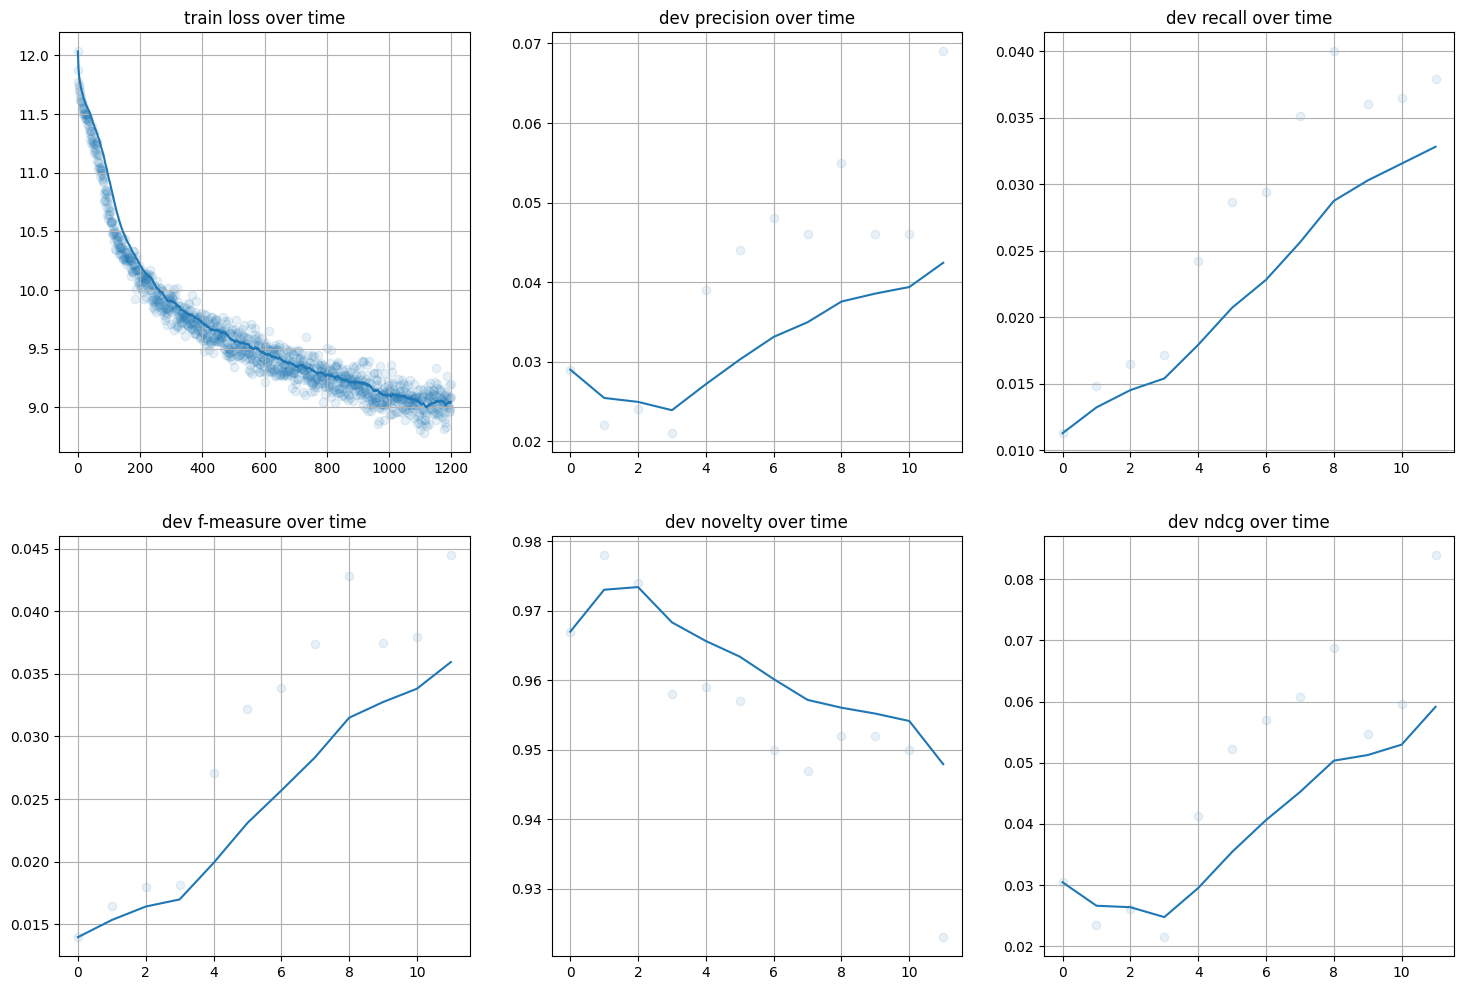

step=1200, mean_loss=9.036, time=1.000
____________________________________________________________________________________________________


In [ ]:
num_batch = math.ceil(test_instances.shape[0]/test_batch_size)

for i in range(tree_num):
    train_model_list[i].trm_model.train()

validation_batch_generator = train_instances.validation_batches(
    validation_instances_file,item_num,batchsize=test_batch_size)

for (batch_x,batch_y) in training_batch_generator:
    print(batch_x,batch_y)
    #loss=train_model.update_model(batch_x,batch_y)
    loss = 0
    for i in range(tree_num):
        loss+=train_model_list[i].update_model(batch_x,batch_y)
    
    loss.backward()
    model_optimizer.step()
    model_optimizer.zero_grad()
    train_loss_history.append(loss.item())
    
    if train_model_list[0].batch_num%5000==0:
        #train_model.trm_model.eval()
        for i in range(tree_num):
            train_model_list[i].trm_model.eval()
        #result_history=train_model.predict(test_instances,topk=topk).numpy()
        result_history=[]
        for j in range(num_batch):
            batch_result_list = []
            batch_user = test_instances[j*test_batch_size:(j+1)*test_batch_size].to(device)
            for i in range(tree_num):
                batch_result_one_tree = train_model_list[i].predict(batch_user,topk=topk)          
                batch_result_list.append(batch_result_one_tree)
            batch_result = torch.cat(batch_result_list,dim=-1)
            batch_result = rerank(batch_user,batch_result,rerank_topk,tree_num)
            result_history.append(batch_result)
        result_history = torch.cat(result_history,dim=0).cpu().numpy()
        test_precision_history.append(precision(result_history,train_instances.test_labels,rerank_topk))
        test_recall_history.append(recall(result_history,train_instances.test_labels))
        test_f_measure_history.append(f_measure(result_history,train_instances.test_labels,rerank_topk))
        test_novelty_history.append(novelty(result_history,test_instances.tolist(),rerank_topk))
        test_hr_history.append(hit_ratio(result_history,train_instances.test_labels))
        test_ndcg_history.append(NDCG(result_history,train_instances.test_labels))
        test_map_history.append(MAP(result_history,train_instances.test_labels,rerank_topk))

        #train_model.trm_model.train()
        for i in range(tree_num):
            train_model_list[i].trm_model.train()
            
    if train_model_list[0].batch_num% 100 == 0:
        
        ###start to test
        #train_model.trm_model.eval()
        for i in range(tree_num):
            train_model_list[i].trm_model.eval()
        test_batch,test_index=validation_batch_generator.__next__()
        test_batch = test_batch.to(device)
        gt_history=[train_instances.validation_labels[i.item()] for i in test_index]
        #result_history=train_model.predict(test_batch,topk=topk).numpy()
        result_history=[]
        for i in range(tree_num):
            result_history.append(train_model_list[i].predict(test_batch,topk=topk))
        result_history = rerank(test_batch, torch.cat(result_history,dim=-1),tree_num=tree_num).cpu().numpy()
        train_precision_history.append(precision(result_history,gt_history,rerank_topk))
        train_recall_history.append(recall(result_history,gt_history))
        train_f_measure_history.append(f_measure(result_history,gt_history,rerank_topk))
        train_novelty_history.append(novelty(result_history,test_batch.tolist(),rerank_topk))
        train_hr_history.append(hit_ratio(result_history,gt_history))
        train_ndcg_history.append(NDCG(result_history,gt_history))
        train_map_history.append(MAP(result_history,gt_history,rerank_topk))
        for i in range(tree_num):
            train_model_list[i].trm_model.train()
            
        clear_output(True)
        plt.figure(figsize=[18, 12])
        plt.subplot(2, 3, 1)
        plt.title('train loss over time'); plt.grid();
        plt.plot(moving_average(train_loss_history, span=50))
        plt.scatter(range(len(train_loss_history)), train_loss_history, alpha=0.1)

        plt.subplot(2, 3, 2)
        plt.title('dev precision over time'); plt.grid();
        plt.plot(moving_average(train_precision_history, span=50))
        plt.scatter(range(len(train_precision_history)), train_precision_history, alpha=0.1)
        plt.plot(50*(np.arange(len(test_precision_history)) + 1), test_precision_history, c='r')
        
        plt.subplot(2, 3, 3)
        plt.title('dev recall over time'); plt.grid();
        plt.plot(moving_average(train_recall_history, span=10))
        plt.scatter(range(len(train_recall_history)), train_recall_history, alpha=0.1)
        plt.plot(50*(np.arange(len(test_recall_history)) + 1), test_recall_history, c='r')
        
        plt.subplot(2, 3, 4)
        plt.title('dev f-measure over time'); plt.grid();
        plt.plot(moving_average(train_f_measure_history, span=10))
        plt.scatter(range(len(train_f_measure_history)), train_f_measure_history, alpha=0.1)
        plt.plot(50*(np.arange(len(test_f_measure_history)) + 1), test_f_measure_history, c='r')
        
        plt.subplot(2, 3, 5)
        plt.title('dev novelty over time'); plt.grid();
        plt.plot(moving_average(train_novelty_history, span=10))
        plt.scatter(range(len(train_novelty_history)), train_novelty_history, alpha=0.1)
        plt.plot(50*(np.arange(len(test_novelty_history)) + 1), test_novelty_history, c='r')
        
        plt.subplot(2, 3, 6)
        plt.title('dev ndcg over time'); plt.grid();
        plt.plot(moving_average(train_ndcg_history, span=10))
        plt.scatter(range(len(train_ndcg_history)), train_ndcg_history, alpha=0.1)
        plt.plot(50*(np.arange(len(test_ndcg_history)) + 1), test_ndcg_history, c='r')
        
        plt.show()
        
        print("step=%i, mean_loss=%.3f, time=%.3f" % 
              (len(train_loss_history), np.mean(train_loss_history[-100:]),1.0))
        print('_' * 100)
    if train_model_list[0].batch_num > total_batch_num:
        break

In [ ]:
# 保存模型
# 保存 encoder
model_file = '../../data/{}/model/{}{}_model_encoder_k{}.pt'.format(data_set_name, init_way, feature_ratio, k)
torch.save(train_model_list[0].trm_model.trm.encoder, model_file)

# 保存 decoder
for tree_id in range(tree_num):
    model_file = '../../data/{}/model/{}{}_model_decoder_tree_id_{}_k{}.pt'.format(data_set_name, init_way, feature_ratio, tree_id, k)
    torch.save(train_model_list[tree_id].trm_model.trm.decoder, model_file)